In [ ]:
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
from google.colab.patches import cv2_imshow

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

**Load the image**

In [ ]:
import zipfile
zip=zipfile.ZipFile('/content/drive/MyDrive/Data Science/Project/Emotion_detection_dataset.zip')
zip.extractall()
zip.close()

In [ ]:
img=cv2.imread('/content/train/angry/im0.png')

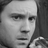

None


In [ ]:
print(cv2_imshow(img))

# **Train and test set**

**Train**

In [ ]:
training_generator=ImageDataGenerator(
    rescale=1./255,
    rotation_range=7,
    horizontal_flip=True,
    zoom_range=0.2)

In [ ]:
train_data=training_generator.flow_from_directory('/content/train',
                                                  target_size=(48,48),
                                                  batch_size=16,
                                                  class_mode='categorical',
                                                  shuffle=True)

Found 28709 images belonging to 7 classes.


In [ ]:
train_data.classes

array([0, 0, 0, ..., 6, 6, 6], dtype=int32)

In [ ]:
np.unique(train_data.classes,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6], dtype=int32),
 array([3995,  436, 4097, 7215, 4965, 4830, 3171]))

In [ ]:
train_data.class_indices

{'angry': 0,
 'disgusted': 1,
 'fearful': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprised': 6}

/tmp/ipykernel_25489/4270001097.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_data.classes,palette='husl')


<Axes: ylabel='count'>

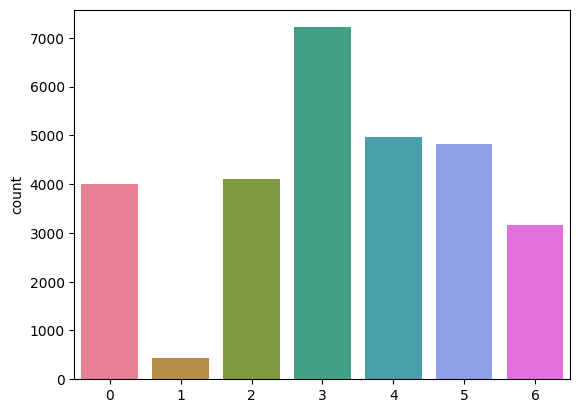

In [ ]:
sns.countplot(x=train_data.classes,palette='husl')

**Test**

In [ ]:
test_generator=ImageDataGenerator(rescale=1./255)
test_data=test_generator.flow_from_directory('/content/test',
                                             target_size=(48,48),
                                             batch_size=1,
                                             class_mode='categorical',
                                             shuffle=False)

Found 7178 images belonging to 7 classes.


## **CNN**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Conv2D,\
                            MaxPooling2D,\
                            Dropout,\
                            BatchNormalization,\
                            Flatten,Dense

In [ ]:
model=Sequential()
model.add(Input(shape=(48,48,3)))

model.add(Conv2D(filters=32,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=32,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))


model.add(Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=128,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Conv2D(filters=256,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(Conv2D(filters=256,kernel_size=(3,3),strides=(1,1),activation='relu',padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(7,activation="softmax"))



In [ ]:
model.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,333,607 (5.09 MB)

 Trainable params: 1,331,303 (5.08 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [ ]:
model.fit(train_data,epochs=70)

Epoch 1/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 72s 30ms/step - accuracy: 0.2606 - loss: 1.8837
Epoch 2/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - accuracy: 0.3778 - loss: 1.5865
Epoch 3/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.4490 - loss: 1.4272
Epoch 4/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.4865 - loss: 1.3442
Epoch 5/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.5112 - loss: 1.2854
Epoch 6/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - accuracy: 0.5372 - loss: 1.2338
Epoch 7/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - accuracy: 0.5521 - loss: 1.2009
Epoch 8/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 46s 26ms/step - accuracy: 0.5693 - loss: 1.1574
Epoch 9/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 50s 28ms/step - accuracy: 0.5776 - loss: 1.1328
Epoch 10/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 47s 26ms/step - accuracy: 0.5886 - loss: 1.1106
Epoch 11/70
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - accuracy: 0.5984 - loss: 1.0865
Epoch 12

**Saving the** **model**

In [ ]:
model_json = model.to_json()
with open('model_emotions.json','w') as json_file:
  json_file.write(model_json)

In [ ]:
from keras.models import save_model
model_saved = save_model(model, '/content/weights_emotions.hdf5')

In [ ]:
with open('/content/model_emotions.json', 'r') as json_file:
  json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 48, 48, 3], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer", "optional": false}, "registered_name": null}, {"module": "keras.layers", "class_name": "Conv2D", "config": {"name": "conv2d", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "filters": 32, "kernel_size": [3, 3], "strides": [1, 1], "padding": "same", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initia

In [ ]:
model_loaded = tf.keras.models.model_from_json(json_saved_model)
model_loaded.load_weights('/content/weights_emotions.hdf5')
model_loaded.compile(loss = 'categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [ ]:
model_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,333,607 (5.09 MB)

 Trainable params: 1,331,303 (5.08 MB)

 Non-trainable params: 2,304 (9.00 KB)

**Evalution**

In [ ]:
model.evaluate(test_data)

7178/7178 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.6754 - loss: 0.9568


[0.9568166136741638, 0.6753970384597778]